In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
#-------------------------------------
# Define a presynaptic pulse spike
#-------------------------------------

def presynaptic_pulse_spike(V_max:float, V_min:float, discerete_times:list, offset:float, delta_t:float) -> np.ndarray:

    t0, t1, t2, t3, t4, t5 = discerete_times

    V = np.array([
        [0., 0., offset+max(0.,-delta_t)],
        [0., V_max, t1-t0],
        [V_max, V_min, t3-t2],
        [V_min,0.,t5-t4],
        [0.,0.,offset+max(0.,delta_t)]
    ])

    return V

#-------------------------------------
# Define a postsynaptic pulse spike
#-------------------------------------

def postsynaptic_pulse_spike(V_max:float, V_min:float, post_times: list, offset:float,delta_t:float) -> np.ndarray:

    t0_p, t1_p, t2_p, t3_p, t4_p, t5_p = post_times

    V_prime = np.array([
        [0., 0., offset+max(0.,delta_t)],
        [0., V_max, t1_p-t0_p],
        [V_max, V_min, t3_p-t2_p],
        [V_min,0.,t5_p-t4_p],
        [0.,0.,offset+max(0.,-delta_t)]
    ])

    return V_prime

    #-------------------------------------
    # Get output points as start channel voltage, end channel voltage, segment
    # time


def save_synaptic_pulses(file_path:str,pre_voltages:list,post_voltages:list) -> None:
    headers = ["pre-voltage (V)", "post-voltage(V)","rise time (s)"]
    header_str = ','.join(headers)
    np.savetxt("pre-"+file_path,pre_voltages,fmt="%16f",delimiter=",",header=header_str)
    np.savetxt("post-"+file_path,post_voltages,fmt="%16f",delimiter=",",header=header_str)

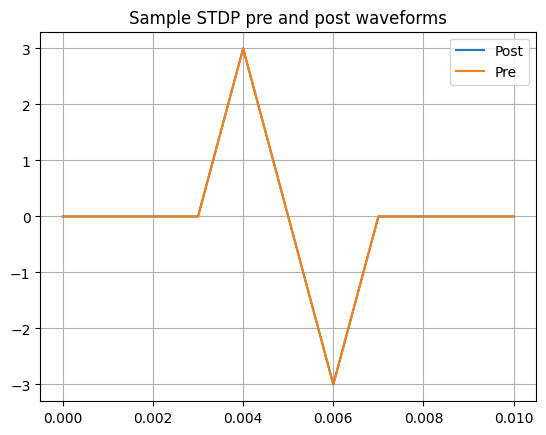

In [12]:
#--------------------------------------------------------------------------
# For STDP waveforms
#--------------------------------------------------------------------------

Trial_num = 1 # start at 1

delta_T = Trial_num//2 * (-1)**Trial_num * 1e-3 # time lag between pre- and post-pulses
delta_t0_p = 15e-3
delta_t2_p = 0e-3
delta_t3_p = 2e-3
delta_t4_p = 2e-3
delta_t5_p = 8e-3

V_start = 0. # start voltage
V_max = 3. # maximum voltage
V_min = -3. #minimum voltage
offset = 3e-3 # padding time in between pulses
vis = True # if True ==> graph the results
same = True

t0 = 0. # start time
t1 = 1e-3
t2 = 1e-3
t3 = 3e-3
t4 = 3e-3
t5 = 4e-3 # end time

if same == 0:
    t1_p = t1+delta_T
    t0_p = t1_p-delta_t0_p
    t2_p = t1_p+delta_t2_p
    t3_p = t1_p+delta_t3_p
    t4_p = t1_p+delta_t4_p
    t5_p = t1_p+delta_t5_p

else: # same == 1
    t1_p = t1+delta_T
    t0_p = t0+delta_T
    t2_p = t2+delta_T
    t3_p = t3+delta_T
    t4_p = t4+delta_T
    t5_p = t5+delta_T


times = [t0,t1,t2,t3,t4,t5]
post_times = [t0_p,t1_p,t2_p,t3_p,t4_p,t5_p]

V = presynaptic_pulse_spike(V_max,V_min, times,offset,delta_T)

V_prime = postsynaptic_pulse_spike(V_max,V_min,post_times, offset,delta_T)

save_synaptic_pulses("synaptic_pulses.csv",V,V_prime)


if vis == 1:
    pre_times = [0.]
    post_times = [0.]
    pre_voltage = [0.]
    post_voltages = [0.]
    for i in range(V.shape[0]):
        pre_times.append(V[i,-1]+pre_times[-1])
        post_times.append(V_prime[i,-1]+post_times[-1])
        pre_voltage.append(V[i,-2])
        post_voltages.append(V_prime[i,-2])

    pre_times[-1] = max(pre_times[-1],post_times[-1])
    post_times[-1] = pre_times[-1]

    plt.plot(pre_times,pre_voltage)
    plt.plot(post_times,post_voltages)
    plt.title('Sample STDP pre and post waveforms')
    plt.legend(['Post','Pre'],loc='upper right')

    plt.grid(True)
    #plt.savefig("Figure_1.png")
    plt.show()

In [ ]:
# gen csvs for trial
import csv as csv

V_start = 0. # start voltage
V_max = 3. # maximum voltage
V_min = -3. #minimum voltage
offset = 3e-3 # padding time in between pulses
vis = True # if True ==> graph the results
same = True

t0 = 0. # start time
t1 = 1e-3
t2 = 1e-3
t3 = 3e-3
t4 = 3e-3
t5 = 4e-3 # end time

times = [t0,t1,t2,t3,t4,t5]

for i in range(1,35):
  delta_T = i//2 * (-1)**i * 1e-3 # time lag between pre- and post-pulses
  with open("./CSVs/pre_synaptic_pulse%i.csv"%i, "w") as f:
    writer = csv.writer(f)
    writer.writerows(presynaptic_pulse_spike(V_max,V_min, times,offset,delta_T))

  with open("./CSVs/post_synaptic_pulse%i.csv"%i, "w") as f:
    writer = csv.writer(f)
    writer.writerows(postsynaptic_pulse_spike(V_max,V_min,times, offset,delta_T))